# 0 Imports

In [97]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import seaborn as sns

from src.suporte import funcoes_suporte as fs

from sklearn import preprocessing as pp

## 0.1 Funções Suporte

In [98]:
fs.jupyter_settings(altura = 10, largura = 14, fonte = 8)
fs.supressao_notacao(casa_decimal = 6)

# 0.2 Load Data

In [99]:
df = fs.load_pickle("../data/interim/3.fe.pkl")
df.sample(5)

,customer_id,faturamento,recencia_days,frequencia,avg_faturamento,retornos
3960,13651,79.200000,39,1,15.840000,0.000000
2552,16116,612.780000,211,1,18.022941,1.000000
145,16781,311.250000,372,1,18.308824,1.000000
269,15880,343.280000,369,1,3.269333,1.000000
4302,16988,126.120000,5,1,18.017143,0.000000


In [100]:
df.columns

Index(['customer_id', 'faturamento', 'recencia_days', 'frequencia',
       'avg_faturamento', 'retornos'],
      dtype='object')

# 1.0 Visualização da Distribuição

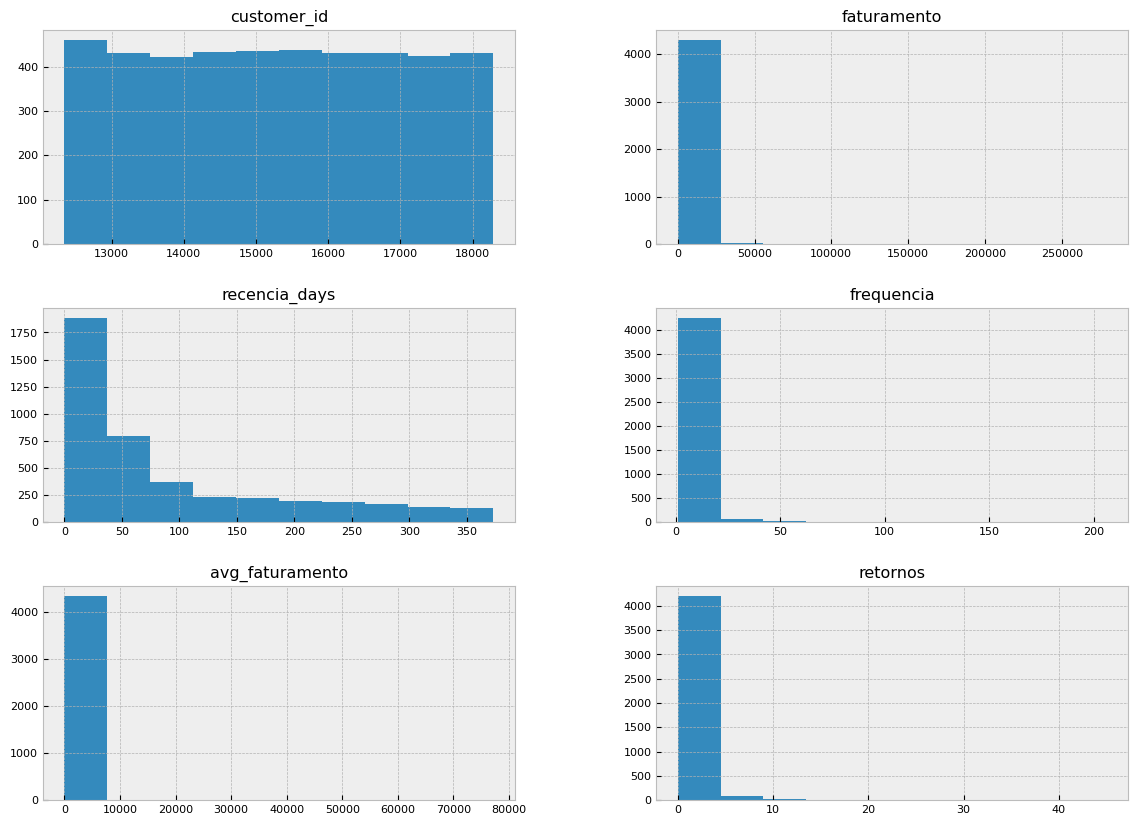

In [101]:
df.hist();

# 2.0 Encoders

# 3.0 Reescala

In [102]:
df.columns

Index(['customer_id', 'faturamento', 'recencia_days', 'frequencia',
       'avg_faturamento', 'retornos'],
      dtype='object')

In [103]:
mms = pp.MinMaxScaler()
ss = pp.StandardScaler()

In [104]:
for col in df.columns:
    if not(col == 'customer_id'):
        df[col] = ss.fit_transform(df[[col]])

In [105]:
for col in df.columns:
    if not(col == 'customer_id'):
        df[col] = np.log1p(df[col])

In [106]:
df.head()

,customer_id,faturamento,recencia_days,frequencia,avg_faturamento,retornos
0,17850,0.320612,1.332992,1.588239,-0.034524,0.108589
1,13047,0.127286,-0.447915,0.483718,-0.033994,1.425017
2,12583,0.422282,-2.301739,0.878639,-0.026979,0.483603
3,13748,-0.128509,0.027758,0.093864,-0.023515,-0.498403
4,15100,-0.137771,1.224712,-0.178448,0.141869,0.755705


# 5.0 Visualização Distribuição

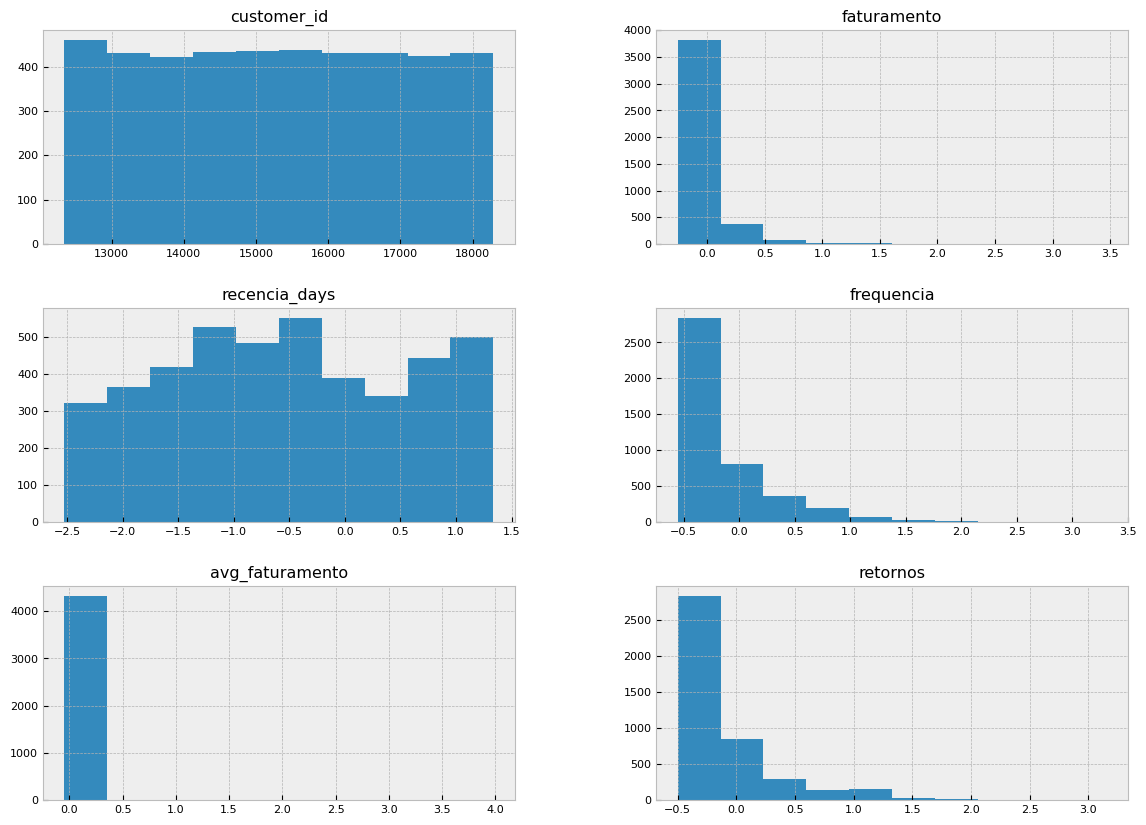

In [107]:
df.hist();

# 4.0 Exportar DF

In [108]:
fs.save_pickle(df,'../data/interim/5.data_prep.pkl')